In [245]:
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader,Dataset
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

In [246]:
device='mps' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [247]:
data_df=pd.read_csv('riceClassification.csv')

In [248]:
data_df

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
18180,18181,5853,148.624571,51.029281,0.939210,6008,86.326537,0.498594,332.960,0.663444,2.912535,0
18181,18182,7585,169.593996,58.141659,0.939398,7806,98.272692,0.647461,385.506,0.641362,2.916910,0
18182,18183,6365,154.777085,52.908085,0.939760,6531,90.023162,0.561287,342.253,0.682832,2.925396,0
18183,18184,5960,151.397924,51.474600,0.940427,6189,87.112041,0.492399,343.371,0.635227,2.941216,0


In [249]:
data_df.isnull()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
18180,False,False,False,False,False,False,False,False,False,False,False,False
18181,False,False,False,False,False,False,False,False,False,False,False,False
18182,False,False,False,False,False,False,False,False,False,False,False,False
18183,False,False,False,False,False,False,False,False,False,False,False,False


In [250]:
data_df.drop(['id'],axis=1,inplace=True)

In [251]:
data_df

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1
...,...,...,...,...,...,...,...,...,...,...,...
18180,5853,148.624571,51.029281,0.939210,6008,86.326537,0.498594,332.960,0.663444,2.912535,0
18181,7585,169.593996,58.141659,0.939398,7806,98.272692,0.647461,385.506,0.641362,2.916910,0
18182,6365,154.777085,52.908085,0.939760,6531,90.023162,0.561287,342.253,0.682832,2.925396,0
18183,5960,151.397924,51.474600,0.940427,6189,87.112041,0.492399,343.371,0.635227,2.941216,0


In [252]:
data_df.shape

(18185, 11)

In [253]:
data_df['Class'].unique()

array([1, 0])

In [254]:
data_df['Class'].value_counts()

Class
1    9985
0    8200
Name: count, dtype: int64

In [255]:
original_df=data_df.copy()

In [256]:
original_df

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1
...,...,...,...,...,...,...,...,...,...,...,...
18180,5853,148.624571,51.029281,0.939210,6008,86.326537,0.498594,332.960,0.663444,2.912535,0
18181,7585,169.593996,58.141659,0.939398,7806,98.272692,0.647461,385.506,0.641362,2.916910,0
18182,6365,154.777085,52.908085,0.939760,6531,90.023162,0.561287,342.253,0.682832,2.925396,0
18183,5960,151.397924,51.474600,0.940427,6189,87.112041,0.492399,343.371,0.635227,2.941216,0


In [257]:
for column in data_df.columns:
    data_df[column] = data_df[column]/data_df[column].abs().max() # Divide by the maximum of the column which will make max value of each column is 1
data_df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


In [258]:
X=np.array(data_df.iloc[:,:-1])

In [259]:
X

array([[0.44436827, 0.50340371, 0.77543522, ..., 0.5370287 , 0.844997  ,
        0.36831616],
       [0.28129285, 0.40768133, 0.62265269, ..., 0.40966075, 0.91921498,
        0.37147093],
       [0.29853085, 0.41642141, 0.63044229, ..., 0.41299402, 0.95986205,
        0.37474651],
       ...,
       [0.62340842, 0.84480035, 0.64091576, ..., 0.67304935, 0.75472018,
        0.74783024],
       [0.58374143, 0.8263563 , 0.62355087, ..., 0.67524793, 0.70210346,
        0.75187447],
       [0.60078355, 0.83554818, 0.62495614, ..., 0.6658912 , 0.74305096,
        0.7585284 ]])

In [260]:
y=np.array(data_df.iloc[:,-1])

In [261]:
y

array([1., 1., 1., ..., 0., 0., 0.])

In [262]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)

In [263]:
 X.shape

(18185, 10)

In [264]:
X_train.shape

(12729, 10)

In [265]:
y_train.shape

(12729,)

In [266]:
print(X_test.shape)
print(y_test.shape)

(5456, 10)
(5456,)


In [267]:
X_test,X_val,y_test,y_val=train_test_split(X_test,y_test,test_size=0.5)

In [268]:
print(X_test.shape,X_val.shape,y_test.shape,y_val.shape)

(2728, 10) (2728, 10) (2728,) (2728,)


In [269]:
class dataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype = torch.float32).to(device)
        self.Y = torch.tensor(Y, dtype = torch.float32).to(device)

    def __len__(self):
        return len(self.X)
    def __getitem__(self, index):
        return self.X[index], self.Y[index]

training_data = dataset(X_train, y_train)
validation_data = dataset(X_val, y_val)
testing_data = dataset(X_test, y_test)

In [270]:
# training_data=dataset(X_train,y_train)
# test_data=dataset(X_val,y_val)
# val_data=dataset(X_test,y_test)

In [271]:
BATCH_SIZE = 32
EPOCHS = 10
HIDDEN_NEURONS = 10
LR = 1e-3

In [272]:
training_data.X

tensor([[0.5158, 0.8243, 0.5447,  ..., 0.6485, 0.6725, 0.8586],
        [0.6138, 0.8690, 0.6170,  ..., 0.6897, 0.7076, 0.7991],
        [0.6010, 0.8613, 0.6137,  ..., 0.6892, 0.6939, 0.7964],
        ...,
        [0.3601, 0.6409, 0.4912,  ..., 0.5233, 0.7213, 0.7403],
        [0.9833, 0.9777, 0.8692,  ..., 0.8065, 0.8290, 0.6381],
        [0.8401, 0.8242, 0.8902,  ..., 0.7220, 0.8838, 0.5253]])

In [273]:
train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle= True)
validation_dataloader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle= True)
testing_dataloader = DataLoader(testing_data, batch_size=BATCH_SIZE, shuffle= True)

In [274]:
for x,y in train_dataloader:
    print(x,'\,',y)

tensor([[0.8510, 0.8547, 0.8698, 0.9192, 0.8184, 0.9225, 0.6516, 0.7472, 0.8361,
         0.5575],
        [0.9291, 0.9035, 0.8918, 0.9264, 0.8786, 0.9639, 0.8578, 0.7727, 0.8534,
         0.5748],
        [0.6071, 0.8639, 0.6140, 0.9799, 0.5793, 0.7791, 0.5408, 0.6884, 0.7025,
         0.7982],
        [0.6951, 0.7720, 0.7883, 0.9184, 0.6652, 0.8337, 0.6788, 0.6792, 0.8263,
         0.5556],
        [0.7548, 0.8270, 0.7979, 0.9315, 0.7137, 0.8688, 0.6520, 0.6975, 0.8510,
         0.5881],
        [0.5938, 0.7950, 0.6538, 0.9607, 0.5615, 0.7706, 0.9443, 0.6475, 0.7767,
         0.6899],
        [0.6262, 0.8060, 0.6778, 0.9572, 0.5953, 0.7914, 0.5816, 0.6639, 0.7792,
         0.6746],
        [0.6868, 0.9284, 0.6447, 0.9824, 0.6508, 0.8287, 0.7209, 0.7321, 0.7027,
         0.8170],
        [0.8501, 0.8226, 0.8975, 0.9007, 0.8084, 0.9220, 0.8135, 0.7204, 0.8983,
         0.5200],
        [0.8545, 0.8671, 0.8579, 0.9259, 0.8168, 0.9244, 0.6390, 0.7487, 0.8359,
         0.5735],
        [0

<>:2: SyntaxWarning: invalid escape sequence '\,'
<>:2: SyntaxWarning: invalid escape sequence '\,'
/var/folders/vy/fch6w1_x1l75t7_9zqnljtt80000gn/T/ipykernel_1246/97753668.py:2: SyntaxWarning: invalid escape sequence '\,'
  print(x,'\,',y)


tensor([[0.5035, 0.7624, 0.5772, 0.9723, 0.4735, 0.7096, 0.9338, 0.6091, 0.7443,
         0.7494],
        [0.5869, 0.8129, 0.6278, 0.9697, 0.5561, 0.7661, 0.8177, 0.6554, 0.7493,
         0.7346],
        [0.5269, 0.8240, 0.5539, 0.9858, 0.4989, 0.7259, 0.6284, 0.6449, 0.6947,
         0.8439],
        [0.5705, 0.8184, 0.6133, 0.9736, 0.5402, 0.7553, 0.5303, 0.6585, 0.7215,
         0.7571],
        [0.6892, 0.9297, 0.6492, 0.9818, 0.6551, 0.8302, 0.4921, 0.7472, 0.6771,
         0.8125],
        [0.6585, 0.8272, 0.6906, 0.9584, 0.6216, 0.8115, 0.9379, 0.6828, 0.7746,
         0.6796],
        [0.8378, 0.8408, 0.8665, 0.9161, 0.7932, 0.9153, 0.7079, 0.7250, 0.8740,
         0.5505],
        [0.4308, 0.6961, 0.5400, 0.9691, 0.4090, 0.6563, 0.5506, 0.5621, 0.7478,
         0.7314],
        [0.8546, 0.8392, 0.8884, 0.9091, 0.8144, 0.9244, 0.7349, 0.7309, 0.8773,
         0.5359],
        [0.5968, 0.9425, 0.5512, 0.9978, 0.5736, 0.7725, 0.4609, 0.7341, 0.6072,
         0.9702],
        [0

In [275]:
class MyModel(nn.Module):
    def __init__(self):

        super(MyModel, self).__init__()

        self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
        self.linear = nn.Linear(HIDDEN_NEURONS, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

In [276]:
model = MyModel().to(device)
summary(model, (X.shape[1],))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]             110
            Linear-2                    [-1, 1]              11
           Sigmoid-3                    [-1, 1]               0
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [277]:
criterion=nn.BCELoss()
optimiser=Adam(model.parameters(),lr=LR)

In [278]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0
    ## Training and Validation
    for data in train_dataloader:

        inputs, labels = data

        prediction = model(inputs).squeeze(1)

        batch_loss = criterion(prediction, labels)

        total_loss_train += batch_loss.item()

        acc = ((prediction).round() == labels).sum().item()

        total_acc_train += acc

        batch_loss.backward()
        optimiser.step()
        optimiser.zero_grad()

    ## Validation
    with torch.no_grad():
        for data in validation_dataloader:
            inputs, labels = data

            prediction = model(inputs).squeeze(1)

            batch_loss = criterion(prediction, labels)

            total_loss_val += batch_loss.item()

            acc = ((prediction).round() == labels).sum().item()

            total_acc_val += acc

    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_validation_plot.append(round(total_loss_val/1000, 4))
    total_acc_train_plot.append(round(total_acc_train/(training_data.__len__())*100, 4))
    total_acc_validation_plot.append(round(total_acc_val/(validation_data.__len__())*100, 4))

    print(f'''Epoch no. {epoch + 1} Train Loss: {total_loss_train/1000:.4f} Train Accuracy: {(total_acc_train/(training_data.__len__())*100):.4f} Validation Loss: {total_loss_val/1000:.4f} Validation Accuracy: {(total_acc_val/(validation_data.__len__())*100):.4f}''')
    print("="*50)
     

Epoch no. 1 Train Loss: 0.2322 Train Accuracy: 87.4853 Validation Loss: 0.0378 Validation Accuracy: 97.4707
Epoch no. 2 Train Loss: 0.1176 Train Accuracy: 97.6982 Validation Loss: 0.0161 Validation Accuracy: 98.2038
Epoch no. 3 Train Loss: 0.0561 Train Accuracy: 98.1774 Validation Loss: 0.0092 Validation Accuracy: 98.4971
Epoch no. 4 Train Loss: 0.0361 Train Accuracy: 98.3424 Validation Loss: 0.0065 Validation Accuracy: 98.5337
Epoch no. 5 Train Loss: 0.0278 Train Accuracy: 98.4209 Validation Loss: 0.0054 Validation Accuracy: 98.6437
Epoch no. 6 Train Loss: 0.0236 Train Accuracy: 98.5073 Validation Loss: 0.0046 Validation Accuracy: 98.6070
Epoch no. 7 Train Loss: 0.0212 Train Accuracy: 98.6330 Validation Loss: 0.0043 Validation Accuracy: 98.7170
Epoch no. 8 Train Loss: 0.0196 Train Accuracy: 98.5702 Validation Loss: 0.0040 Validation Accuracy: 98.6437
Epoch no. 9 Train Loss: 0.0185 Train Accuracy: 98.6016 Validation Loss: 0.0040 Validation Accuracy: 98.6070
Epoch no. 10 Train Loss: 0.0

In [279]:
train_dataloader

testing

In [292]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for data in testing_dataloader:
    inputs, labels = data

    prediction = model(inputs).squeeze(1)

    batch_loss_test = criterion((prediction), labels)
    total_loss_test += batch_loss_test.item()
    # acc_score=accuracy_score(prediction.round(),labels)
    acc = ((prediction).round() == labels).sum().item()
    total_acc_test += acc
print(f"Accuracy Score is: {round((total_acc_test/X_test.shape[0])*100, 2)}%")
# print(acc_score)


Accuracy Score is: 98.9%


plotting and visualizations

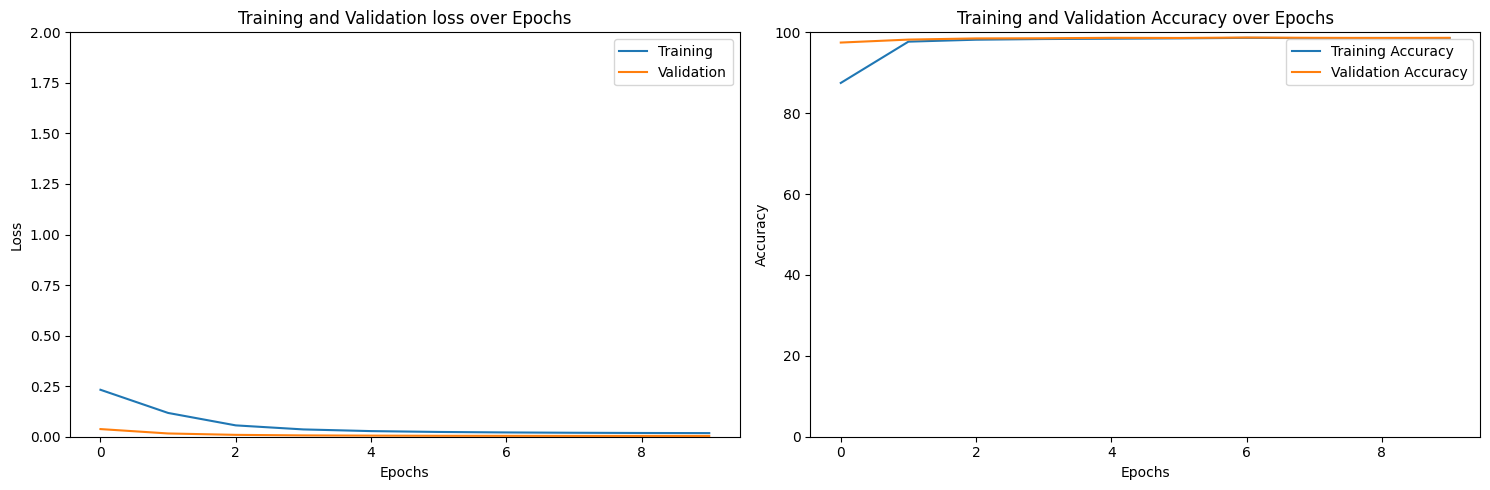

In [306]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))
axs[0].plot(total_loss_train_plot,label='Training')
axs[0].plot(total_loss_validation_plot,label='Validation')
axs[0].set_title("Training and Validation loss over Epochs")
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0,2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()
plt.tight_layout()

plt.show()
